# LinkedIn job postings — salary, remote status, description clusters

Three models on one preprocessing base. Salary regression is the main one; the remote
classifier and the description clustering are lighter passes over the same table.

Data is the 2023–24 LinkedIn scrape: `postings.csv` is the spine, with salaries, skills,
industries and company attributes in separate files because a job maps to many skills and
many industries.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              StackingRegressor)
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve, silhouette_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 60)

BASE = 'data'
p = lambda *a: os.path.join(BASE, *a)

In [2]:
KEEP = ['job_id', 'company_id', 'company_name', 'title', 'location',
        'formatted_work_type', 'work_type', 'formatted_experience_level',
        'remote_allowed', 'sponsored', 'views', 'applies',
        'listed_time', 'expiry', 'zip_code', 'fips',
        'min_salary', 'med_salary', 'max_salary', 'pay_period', 'currency',
        'compensation_type', 'normalized_salary']

postings = pd.read_csv(p('postings.csv'), usecols=KEEP, low_memory=False)

salaries       = pd.read_csv(p('jobs', 'salaries.csv'))
job_skills     = pd.read_csv(p('jobs', 'job_skills.csv'))
job_industries = pd.read_csv(p('jobs', 'job_industries.csv'))
benefits       = pd.read_csv(p('jobs', 'benefits.csv'))
companies      = pd.read_csv(p('companies', 'companies.csv'), low_memory=False)
company_ind    = pd.read_csv(p('companies', 'company_industries.csv'))
company_spec   = pd.read_csv(p('companies', 'company_specialities.csv'))
emp_counts     = pd.read_csv(p('companies', 'employee_counts.csv'))
skills_map     = pd.read_csv(p('mappings', 'skills.csv'))
industries_map = pd.read_csv(p('mappings', 'industries.csv'))

postings.shape

(123849, 23)

In [3]:
postings.dtypes

job_id                          int64
company_name                   object
title                          object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
remote_allowed                float64
expiry                        float64
formatted_experience_level     object
listed_time                   float64
sponsored                       int64
work_type                      object
currency                       object
compensation_type              object
normalized_salary             float64
zip_code                      float64
fips                          float64
dtype: object

In [4]:
salary_cols = ['min_salary', 'med_salary', 'max_salary']
has_salary = postings[salary_cols].notna().any(axis=1)

print(f'postings            {len(postings):>8,}')
print(f'with any salary     {has_salary.sum():>8,}  ({has_salary.mean():.1%})')
print(f'in salaries.csv     {postings.job_id.isin(salaries.job_id).sum():>8,}')
print()
print(salaries[salary_cols].notna().value_counts().to_string())

postings             123,849
with any salary       36,073  (29.1%)
in salaries.csv       36,073

min_salary  med_salary  max_salary
True        False       True          33947
False       True        False          6838


In [5]:
print(salaries.pay_period.value_counts().to_string())
print()
print(salaries.currency.value_counts().head().to_string())
print()
print(salaries.compensation_type.value_counts().to_string())

pay_period
YEARLY      23768
HOURLY      16289
MONTHLY       539
WEEKLY        180
BIWEEKLY        9

currency
USD    40770
EUR        6
CAD        3
BBD        2
AUD        2

compensation_type
BASE_SALARY    40785


Two things fall out of that.

Salary is present on 29% of postings, so the regression trains on ~35k rows rather than 124k.
Disclosure is not random — it tracks pay-transparency laws (CA, CO, NY, WA) and larger
employers — so the model describes salary-disclosing postings, not the job market. Worth
stating once and keeping in mind when reading the R².

`min`/`max` and `med` are mutually exclusive: 33,947 rows carry a range with no median, 6,838
carry a median with no range, none carry both. So the target is `med` where it exists and the
midpoint of the range otherwise. Taking only one of the two paths throws away most of the labels.

In [6]:
chunks, text_sample = [], []
for chunk in pd.read_csv(p('postings.csv'), usecols=['job_id', 'description'],
                         chunksize=20_000, low_memory=False):
    txt = chunk.description.fillna('')
    chunks.append(pd.DataFrame({'job_id': chunk.job_id,
                                'desc_word_count': txt.str.split().str.len(),
                                'desc_char_count': txt.str.len()}))
    text_sample.append(chunk.sample(frac=0.2, random_state=SEED))

desc_feats  = pd.concat(chunks, ignore_index=True)
descriptions = pd.concat(text_sample, ignore_index=True).dropna(subset=['description'])
del chunks, text_sample

print(desc_feats.shape, descriptions.shape)
desc_feats.desc_word_count.describe().round(0)

(123849, 3) (24770, 2)


count    123849.0
mean        523.0
std         302.0
min           0.0
25%         298.0
50%         477.0
75%         696.0
max        3400.0
Name: desc_word_count, dtype: float64

In [7]:
sal = salaries.copy()
sal['point'] = sal.med_salary.fillna(sal[['min_salary', 'max_salary']].mean(axis=1))

MULT = {'HOURLY': 2080, 'DAILY': 260, 'WEEKLY': 52, 'BIWEEKLY': 26, 'MONTHLY': 12, 'YEARLY': 1}
sal['annual'] = sal.point * sal.pay_period.str.upper().map(MULT)

sal.groupby('pay_period')[['point', 'annual']].median().round(0)

,point,annual
pay_period,,
BIWEEKLY,60492.0,1572805.0
HOURLY,25.0,52000.0
MONTHLY,4308.0,51702.0
WEEKLY,2099.0,109148.0
YEARLY,103000.0,103000.0


In [8]:
sal[sal.pay_period == 'BIWEEKLY'][['min_salary', 'max_salary', 'point', 'annual']]

,min_salary,max_salary,point,annual
11759,2057.0,2057.0,2057.0,53482.0
17733,54009.0,66976.0,60492.5,1572805.0
18104,71323.0,89965.0,80644.0,2096744.0
19960,2134.0,2134.0,2134.0,55484.0
21877,64519.0,81434.0,72976.5,1897389.0
22552,2245.0,3366.0,2805.5,72943.0
24004,69496.0,87660.0,78578.0,2043028.0
29797,54009.0,66976.0,60492.5,1572805.0
39418,62639.0,81459.0,72049.0,1873274.0


Nine biweekly rows, and they are not one problem but two. Six hold annual figures in a
biweekly field — a $60,492 'biweekly' cheque annualises to $1.57M — and the $500k ceiling
below removes those six. The other three are genuine biweekly pay ($2,057, $2,134, $2,806
per period, annualising to $53k–$73k) and they correctly survive.

So the filter drops 6 of the 9, not all of them. The per-period median reads $1.57M only
because two thirds of the group is broken — which is why it is worth printing rather than
assuming.

In [9]:
before = len(sal)
sal = sal[sal.currency == 'USD']
sal = sal[sal.annual.between(10_000, 500_000)]

print(f'{before:,} -> {len(sal):,}  ({before - len(sal):,} dropped: non-USD + implausible)')

salary_target = sal.groupby('job_id', as_index=False).annual.median()
salary_target.annual.describe().round(0)

40,785 -> 40,228  (557 dropped: non-USD + implausible)


count     40228.0
mean      96664.0
std       57418.0
min       10000.0
25%       52000.0
50%       83000.0
75%      125328.0
max      500000.0
Name: annual, dtype: float64

skew  raw 1.56   log 0.06


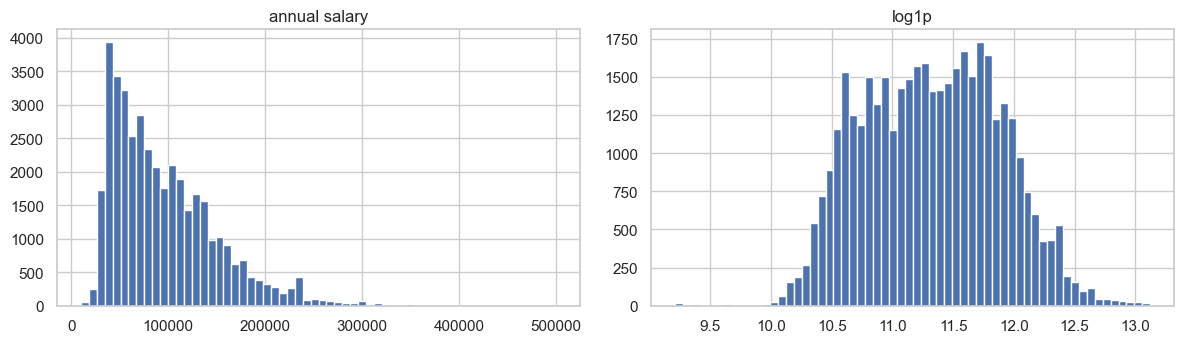

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(salary_target.annual, bins=60, color='#4C72B0')
ax[0].set_title('annual salary')
ax[1].hist(np.log1p(salary_target.annual), bins=60, color='#4C72B0')
ax[1].set_title('log1p')
plt.tight_layout()

print(f'skew  raw {salary_target.annual.skew():.2f}   log {np.log1p(salary_target.annual).skew():.2f}')

Right-skewed, as pay always is. Training on `log1p` makes the error proportional — being $10k
out on a $50k job counts like being $100k out on a $500k job, which is how anyone would judge
it. Errors get reported back in dollars via `expm1`.

In [11]:
postings.title.value_counts().head(15)

title
Sales Manager                      673
Customer Service Representative    373
Project Manager                    354
Administrative Assistant           254
Senior Accountant                  238
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist                       204
Staff Accountant                   200
Account Executive                  195
Retail Sales Associate             190
Sales Associate                    189
Software Engineer                  181
Controller                         175
Name: count, dtype: int64

In [12]:
postings.company_name.value_counts().head(10)

company_name
Liberty Healthcare and Rehabilitation Services    1108
The Job Network                                   1003
J. Galt                                            604
TEKsystems                                         529
Lowe's Companies, Inc.                             527
Ingersoll Rand                                     517
Capital One                                        496
Cogent Communications                              476
Insight Global                                     418
Dice                                               415
Name: count, dtype: int64

In [13]:
postings.remote_allowed.value_counts(dropna=False)

remote_allowed
NaN    108603
1.0     15246
Name: count, dtype: int64

In [14]:
# NaN is not missing here -- the column only ever holds 1.0, so absence means on-site.
postings['is_remote'] = postings.remote_allowed.fillna(0).astype(int)
postings.is_remote.mean()

np.float64(0.12310151878497202)

In [15]:
print(postings[['views', 'applies', 'sponsored']].describe().round(1).to_string())
print()
print('null%', (postings[['views', 'applies', 'sponsored']].isna().mean() * 100).round(1).to_dict())
print('sponsored uniques:', postings.sponsored.unique())

          views  applies  sponsored
count  122160.0  23320.0   123849.0
mean       14.6     10.6        0.0
std        85.9     29.0        0.0
min         1.0      1.0        0.0
25%         3.0      1.0        0.0
50%         4.0      3.0        0.0
75%         8.0      8.0        0.0
max      9975.0    967.0        0.0

null% {'views': 1.4, 'applies': 81.2, 'sponsored': 0.0}
sponsored uniques: [0]


In [16]:
pd.crosstab(postings.work_type, postings.formatted_work_type)

formatted_work_type,Contract,Full-time,Internship,Other,Part-time,Temporary,Volunteer
work_type,,,,,,,
CONTRACT,12117,0,0,0,0,0,0
FULL_TIME,0,98814,0,0,0,0,0
INTERNSHIP,0,0,983,0,0,0,0
OTHER,0,0,0,487,0,0,0
PART_TIME,0,0,0,0,9696,0,0
TEMPORARY,0,0,0,0,0,1190,0
VOLUNTEER,0,0,0,0,0,0,562


In [17]:
postings[['zip_code', 'fips']].head()

,zip_code,fips
0,8540.0,34021.0
1,80521.0,8069.0
2,45202.0,39061.0
3,11040.0,36059.0
4,52601.0,19057.0


formatted_experience_level
Internship           48880.0
Entry level          52500.0
Associate            74937.2
Mid-Senior level    108020.0
Director            166912.5
Executive           191270.0
Name: annual, dtype: float64

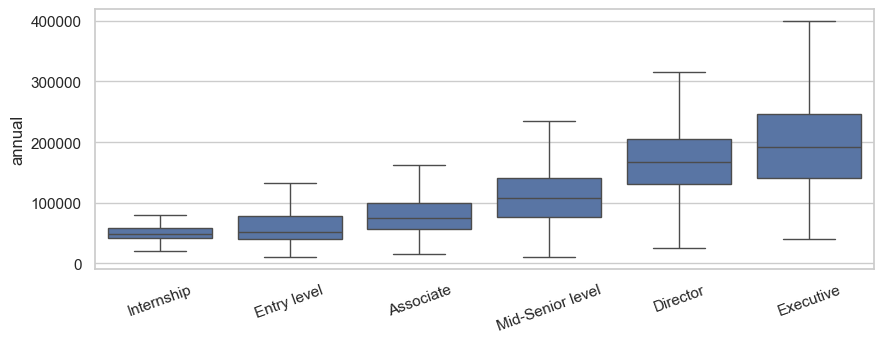

In [18]:
exp_sal = (postings[['job_id', 'formatted_experience_level']]
           .merge(salary_target, on='job_id'))

order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.boxplot(data=exp_sal, x='formatted_experience_level', y='annual',
            order=order, showfliers=False, ax=ax)
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()

exp_sal.groupby('formatted_experience_level').annual.median().reindex(order)

In [19]:
state = postings.location.fillna('').str.rsplit(',', n=1).str[-1].str.strip()
postings['job_state'] = state.where(state.str.fullmatch(r'[A-Z]{2}'))

print(f'parsed {postings.job_state.notna().mean():.1%}')
postings.job_state.value_counts().head(10)

parsed 84.9%


job_state
CA    11484
TX    10271
NY     6044
FL     5907
NC     4927
IL     4480
PA     4133
VA     3660
MA     3489
OH     3421
Name: count, dtype: int64

In [20]:
skills = (job_skills.assign(v=1)
          .pivot_table(index='job_id', columns='skill_abr', values='v',
                       aggfunc='max', fill_value=0))
skills['n_skills'] = skills.sum(axis=1)
skills.columns = [c if c == 'n_skills' else f'skill_{c}' for c in skills.columns]
skills = skills.reset_index()

skills.shape

(126807, 37)

In [21]:
job_ind = job_industries.merge(industries_map, on='industry_id', how='left')

ind_agg = (job_ind.groupby('job_id').size().reset_index(name='n_industries')
           .merge(job_ind.sort_values(['job_id', 'industry_id'])
                  .drop_duplicates('job_id')[['job_id', 'industry_name']]
                  .rename(columns={'industry_name': 'job_industry'}),
                  on='job_id', how='left'))

TOP_BEN = benefits.type.value_counts().head(8).index
ben_wide = (benefits[benefits.type.isin(TOP_BEN)].assign(v=1)
            .pivot_table(index='job_id', columns='type', values='v',
                         aggfunc='max', fill_value=0))
ben_wide.columns = ['benefit_' + c.lower().replace(' ', '_').replace('(', '').replace(')', '')
                    for c in ben_wide.columns]
ben_wide = (ben_wide.reset_index()
            .merge(benefits.groupby('job_id').size().reset_index(name='n_benefits'),
                   on='job_id', how='outer'))

print(ind_agg.shape, ben_wide.shape)

(127125, 3) (30023, 10)


In [22]:
# employee_counts is a time series (1.46 rows/company); keep the latest snapshot or the
# merge fans postings out.
latest = (emp_counts.sort_values('time_recorded')
          .drop_duplicates('company_id', keep='last')
          [['company_id', 'employee_count', 'follower_count']])

company = (companies[['company_id', 'company_size', 'country']]
           .rename(columns={'country': 'company_country'})
           .merge(latest, on='company_id', how='left')
           .merge(company_ind.drop_duplicates('company_id')
                  .rename(columns={'industry': 'company_industry'}),
                  on='company_id', how='left')
           .merge(company_spec.groupby('company_id').size()
                  .reset_index(name='n_specialities'),
                  on='company_id', how='left'))

assert company.company_id.is_unique
company.shape

(24473, 7)

In [23]:
df = postings.copy()
for right, key in [(desc_feats, 'job_id'), (skills, 'job_id'), (ben_wide, 'job_id'),
                   (ind_agg, 'job_id'), (company, 'company_id')]:
    n = len(df)
    df = df.merge(right, on=key, how='left')
    assert len(df) == n, f'fan-out on {key}: {n:,} -> {len(df):,}'

print(df.shape)

(123849, 80)


In [24]:
count_cols = (['n_skills', 'n_benefits', 'n_industries', 'n_specialities']
              + [c for c in df.columns if c.startswith(('skill_', 'benefit_'))])
df[count_cols] = df[count_cols].fillna(0)

EXP = {'Internship': 0, 'Entry level': 1, 'Associate': 2,
       'Mid-Senior level': 3, 'Director': 4, 'Executive': 5}
df['exp_level_num'] = df.formatted_experience_level.map(EXP)
df['exp_missing'] = df.formatted_experience_level.isna().astype(int)

title = df.title.fillna('').str.lower()
df['title_word_count'] = title.str.split().str.len()
for kw in ['senior', 'junior', 'manager', 'director', 'engineer', 'analyst', 'intern']:
    df[f'title_{kw}'] = title.str.contains(kw, regex=False).astype(int)

listed = pd.to_datetime(df.listed_time, unit='ms', errors='coerce')
df['post_dayofweek'] = listed.dt.dayofweek
df['listing_days'] = (pd.to_datetime(df.expiry, unit='ms', errors='coerce') - listed).dt.days

for c in ['employee_count', 'follower_count']:
    df[f'log_{c}'] = np.log1p(df[c])

print(listed.min(), '->', listed.max())
df.shape

2024-03-24 21:50:14 -> 2024-04-20 00:26:56


(123849, 94)

In [25]:
NUMERIC = (['n_skills', 'n_benefits', 'n_industries', 'n_specialities',
            'exp_level_num', 'exp_missing', 'company_size',
            'log_employee_count', 'log_follower_count',
            'desc_word_count', 'desc_char_count', 'title_word_count',
            'post_dayofweek', 'listing_days']
           + [c for c in df.columns if c.startswith(('skill_', 'benefit_', 'title_'))
              and c != 'title_word_count'])

# company_state is unusable -- 416 values mixing codes, full names and '0' placeholders.
CATEGORICAL = ['formatted_work_type', 'job_state', 'job_industry',
               'company_industry', 'company_country']

print(f'{len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical')
df[CATEGORICAL].nunique()

64 numeric, 5 categorical


formatted_work_type      7
job_state               53
job_industry           363
company_industry       144
company_country         81
dtype: int64

## Task 1 — salary regression

In [26]:
model_df = df.merge(salary_target, on='job_id', how='inner')

X = model_df[NUMERIC + CATEGORICAL + ['is_remote']]
y = np.log1p(model_df.annual)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f'{len(df):,} postings -> {len(model_df):,} with salary -> '
      f'{len(X_train):,} train / {len(X_test):,} test')

123,849 postings -> 35,546 with salary -> 28,436 train / 7,110 test


In [27]:
num_cols = NUMERIC + ['is_remote']

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                      ('oh', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                           min_frequency=40, sparse_output=False))]),
     CATEGORICAL),
])

pre.fit(X_train)
print(pre.transform(X_train[:5]).shape[1], 'features after encoding')

290 features after encoding


In [28]:
results = []

def evaluate(name, model, cv=5):
    folds = KFold(cv, shuffle=True, random_state=SEED)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=folds, scoring='r2')

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    d_true, d_pred = np.expm1(y_test), np.expm1(pred)
    row = {'model': name,
           'cv_r2': cv_r2.mean(), 'cv_sd': cv_r2.std(),
           'test_r2': r2_score(y_test, pred),
           'mae_$': mean_absolute_error(d_true, d_pred),
           'rmse_$': np.sqrt(mean_squared_error(d_true, d_pred))}
    results.append(row)
    print(f"{name:<22} cv {row['cv_r2']:.3f} +/-{row['cv_sd']:.3f}   "
          f"test {row['test_r2']:.3f}   MAE ${row['mae_$']:,.0f}")
    return model

pipe = lambda est: Pipeline([('pre', pre), ('est', est)])

In [29]:
evaluate('dummy (median)', pipe(DummyRegressor(strategy='median')))
evaluate('linear', pipe(LinearRegression()))

dummy (median)         cv -0.000 +/-0.000   test -0.000   MAE $42,297


linear                 cv 0.522 +/-0.013   test 0.521   MAE $28,250


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                   'skill_ENG', 'skill_FIN',
                                                   'skill_GENB', 'skill_HCPR',
                                                   'skill_HR', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=40,
                                                                                 sparse_output=False))]),
                                                  ['formatted_work_type',
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est', LinearRegression())])

In [30]:
for a in [0.1, 1.0, 10.0, 100.0]:
    s = cross_val_score(pipe(Ridge(alpha=a)), X_train, y_train,
                        cv=KFold(5, shuffle=True, random_state=SEED), scoring='r2')
    print(f'ridge alpha={a:<6} {s.mean():.4f}')

ridge alpha=0.1    0.5215


ridge alpha=1.0    0.5216


ridge alpha=10.0   0.5221


ridge alpha=100.0  0.5200


In [31]:
evaluate('ridge', pipe(Ridge(alpha=10.0)))
evaluate('lasso', pipe(Lasso(alpha=0.001)))

ridge                  cv 0.522 +/-0.013   test 0.521   MAE $28,243


lasso                  cv 0.506 +/-0.011   test 0.502   MAE $28,815


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                   'skill_ENG', 'skill_FIN',
                                                   'skill_GENB', 'skill_HCPR',
                                                   'skill_HR', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=40,
                                                                                 sparse_output=False))]),
                                                  ['formatted_work_type',
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est', Lasso(alpha=0.001))])

In [32]:
evaluate('random forest', pipe(RandomForestRegressor(
    n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=SEED)))

random forest          cv 0.633 +/-0.014   test 0.641   MAE $23,621


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=40,
                                                                                 sparse_output=False))]),
                                                  ['formatted_work_type',
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [33]:
evaluate('lightgbm', pipe(lgb.LGBMRegressor(
    n_estimators=600, learning_rate=0.05, num_leaves=63,
    random_state=SEED, n_jobs=-1, verbose=-1)))

evaluate('xgboost', pipe(xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=7,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbosity=0)))

evaluate('catboost', pipe(CatBoostRegressor(
    iterations=600, learning_rate=0.05, depth=7,
    random_seed=SEED, verbose=0)))

lightgbm               cv 0.642 +/-0.013   test 0.649   MAE $23,918


xgboost                cv 0.636 +/-0.014   test 0.641   MAE $24,261


catboost               cv 0.599 +/-0.012   test 0.600   MAE $25,822


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=40,
                                                                                 sparse_output=False))]),
                                                  ['formatted_work_type',
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est',
                 CatBoostRegressor(depth=7, iterations=600, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0))])

In [34]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
    }
    m = pipe(lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1))
    return cross_val_score(m, X_train, y_train, scoring='r2',
                           cv=KFold(3, shuffle=True, random_state=SEED)).mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f'best 3-fold r2 {study.best_value:.4f}')
study.best_params

best 3-fold r2 0.6555


{'n_estimators': 1105,
 'learning_rate': 0.028520324955602066,
 'num_leaves': 188,
 'min_child_samples': 5,
 'subsample': 0.7036800441693342,
 'colsample_bytree': 0.8638687768356054,
 'reg_lambda': 0.008256538582505605}

In [35]:
tuned = lgb.LGBMRegressor(**study.best_params, random_state=SEED, n_jobs=-1, verbose=-1)
evaluate('lightgbm tuned', pipe(tuned))

lightgbm tuned         cv 0.664 +/-0.013   test 0.672   MAE $22,733


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                                                 sparse_output=False))]),
                                                  ['formatted_work_type',
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est',
                 LGBMRegressor(colsample_bytree=0.8638687768356054,
                               learning_rate=0.028520324955602066,
                               min_child_samples=5, n_estimators=1105,
                               n_jobs=-1, num_leaves=188, random_state=42,
                               reg_lambda=0.008256538582505605,
                               subsample=0.7036800441693342, verbose=-1))])

In [36]:
stack = StackingRegressor(
    estimators=[
        ('lgb', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                  random_state=SEED, n_jobs=-1, verbose=-1)),
        ('rf',  RandomForestRegressor(n_estimators=150, min_samples_leaf=2,
                                      n_jobs=-1, random_state=SEED)),
        ('ridge', Ridge(alpha=10.0)),
    ],
    final_estimator=Ridge(alpha=1.0), cv=3, n_jobs=1)

evaluate('stacking', pipe(stack), cv=3)

stacking               cv 0.636 +/-0.008   test 0.651   MAE $23,517


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['n_skills', 'n_benefits',
                                                   'n_industries',
                                                   'n_specialities',
                                                   'exp_level_num',
                                                   'exp_missing',
                                                   'company_size',
                                                   'log_employee_count',
                                                   'log_follower_count',
                                                   'desc_word_count',
                                                   'desc_char_count',
                                                   'title_word_count',
                                                   'post_...
                                                   'job_state', 'job_industry',
                                                   'company_industry',
                                                   'company_country'])])),
                ('est',
                 StackingRegressor(cv=3,
                                   estimators=[('lgb',
                                                LGBMRegressor(learning_rate=0.05,
                                                              n_estimators=500,
                                                              n_jobs=-1,
                                                              random_state=42,
                                                              verbose=-1)),
                                               ('rf',
                                                RandomForestRegressor(min_samples_leaf=2,
                                                                      n_estimators=150,
                                                                      n_jobs=-1,
                                                                      random_state=42)),
                                               ('ridge', Ridge(alpha=10.0))],
                                   final_estimator=Ridge(), n_jobs=1))])

In [37]:
board = pd.DataFrame(results).sort_values('test_r2', ascending=False).reset_index(drop=True)
board.round(3)

,model,cv_r2,cv_sd,test_r2,mae_$,rmse_$
0,lightgbm tuned,0.664,0.013,0.672,22733.414,36360.313
1,stacking,0.636,0.008,0.651,23516.575,37564.001
2,lightgbm,0.642,0.013,0.649,23917.616,37526.241
3,random forest,0.633,0.014,0.641,23621.318,38226.580
4,xgboost,0.636,0.014,0.641,24261.250,38114.388
5,catboost,0.599,0.012,0.600,25821.948,40028.502
6,ridge,0.522,0.013,0.521,28242.832,43579.355
7,linear,0.522,0.013,0.521,28250.044,43572.379
8,lasso,0.506,0.011,0.502,28814.869,44308.431
9,dummy (median),-0.000,0.000,-0.000,42297.227,58895.377


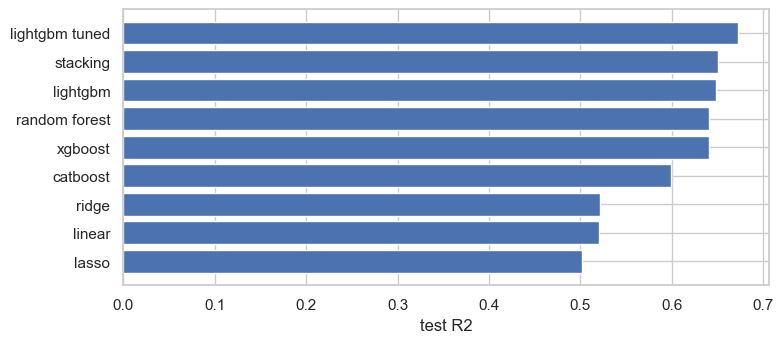

In [38]:
fig, ax = plt.subplots(figsize=(8, 3.6))
b = board[board.model != 'dummy (median)']
ax.barh(b.model[::-1], b.test_r2[::-1], color='#4C72B0')
ax.set_xlabel('test R2')
plt.tight_layout()

Tuned LightGBM: CV R2 0.664 +/- 0.013, test 0.672, MAE $22,733. CV and test agree, so this is
not an overfit.

That is well above the ~0.35 usually quoted for this dataset, and the reason is the label count
rather than the model. `med_salary` alone gives 6,838 training rows; falling back to the
midpoint of `min`/`max` gives 40,228, of which 28,436 end up in train. Four times the data,
plus company size and follower count actually populated rather than silently NaN.

Read the R2 with the dollar figures next to it. It is computed on log salary, where variance is
compressed. In dollars the MAE is $22.7k against a median salary of $82.5k, and only 54.5% of
predictions land within +/-20% of actual. The model is useful for ranking roles, not for quoting
a number to a candidate.

The jump from linear (0.521) to trees (0.672) is large, so there is real interaction structure
here -- pay depends on seniority *within* an industry *within* a state, not on those additively.

What is still missing is the specific role, the tech stack, the city rather than the state, and
the candidate's own experience. And every number above describes salary-disclosing postings only.

within +/-20%: 54.5%


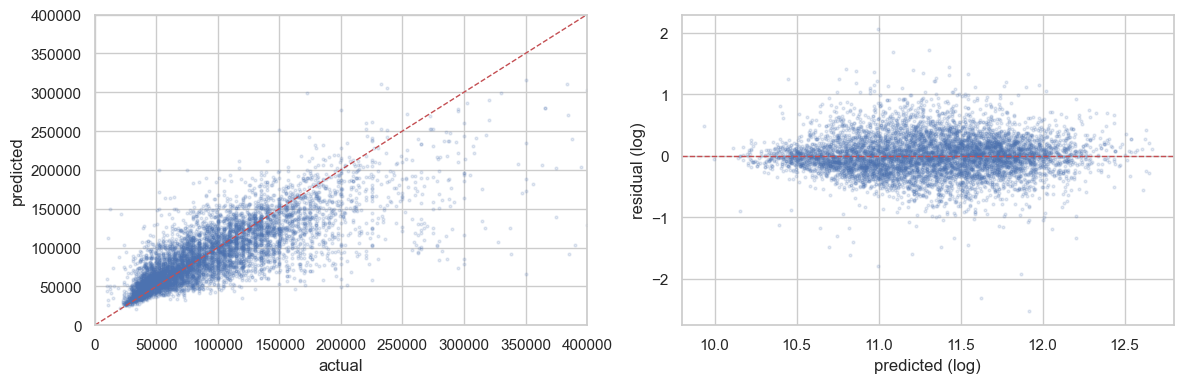

In [39]:
best_model = pipe(lgb.LGBMRegressor(**study.best_params, random_state=SEED,
                                    n_jobs=-1, verbose=-1)).fit(X_train, y_train)
pred = best_model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(np.expm1(y_test), np.expm1(pred), s=4, alpha=0.15, color='#4C72B0')
ax[0].plot([0, 400_000], [0, 400_000], 'r--', lw=1)
ax[0].set_xlim(0, 400_000); ax[0].set_ylim(0, 400_000)
ax[0].set_xlabel('actual'); ax[0].set_ylabel('predicted')

resid = y_test - pred
ax[1].scatter(pred, resid, s=4, alpha=0.15, color='#4C72B0')
ax[1].axhline(0, color='r', ls='--', lw=1)
ax[1].set_xlabel('predicted (log)'); ax[1].set_ylabel('residual (log)')
plt.tight_layout()

print(f'within +/-20%: {(np.abs(np.expm1(pred) - np.expm1(y_test)) / np.expm1(y_test) < 0.2).mean():.1%}')

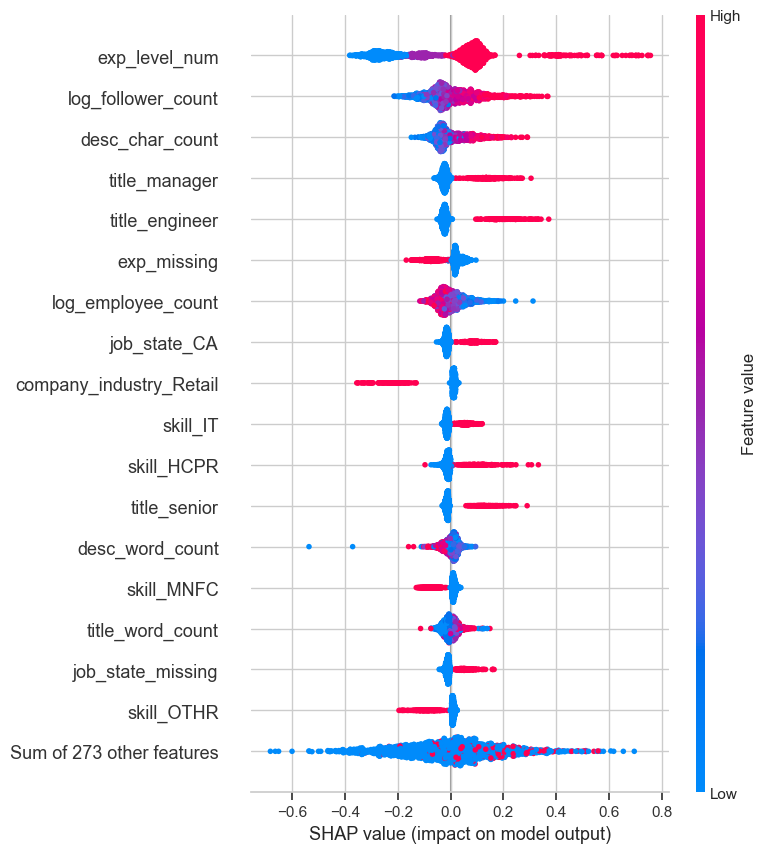

In [40]:
Xt = best_model.named_steps['pre'].transform(X_test)
names = best_model.named_steps['pre'].get_feature_names_out()
names = [n.split('__', 1)[-1] for n in names]

sample = shap.sample(pd.DataFrame(Xt, columns=names), 2000, random_state=SEED)
explainer = shap.TreeExplainer(best_model.named_steps['est'])
sv = explainer(sample)

shap.plots.beeswarm(sv, max_display=18, show=False)
plt.tight_layout()
plt.show()

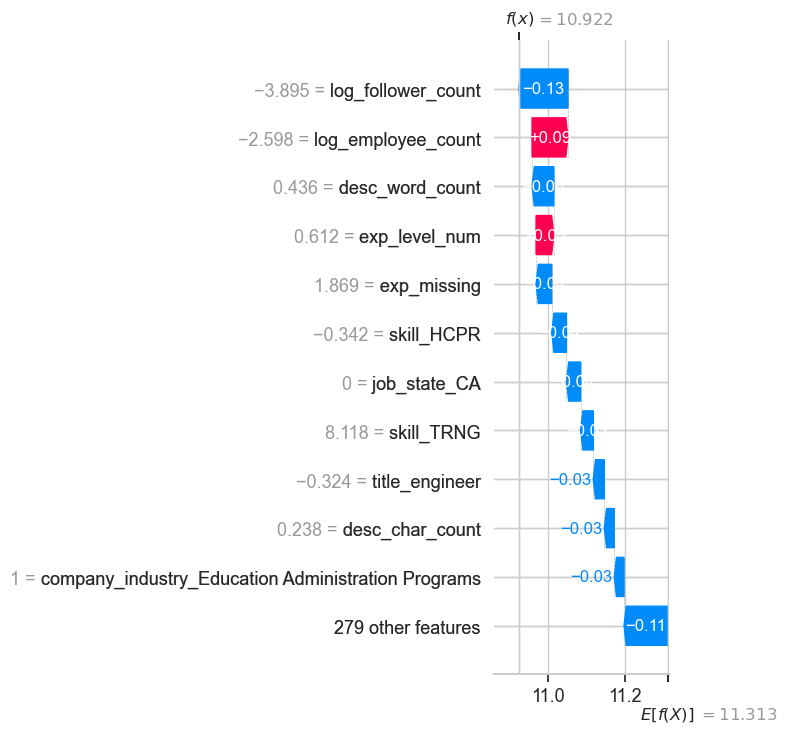

In [41]:
shap.plots.waterfall(sv[0], max_display=12, show=False)
plt.tight_layout()
plt.show()

In [42]:
imp = (pd.Series(np.abs(sv.values).mean(0), index=names)
       .sort_values(ascending=False).head(15))
imp.round(4)

exp_level_num              0.1526
log_follower_count         0.0660
desc_char_count            0.0499
title_manager              0.0421
title_engineer             0.0401
exp_missing                0.0378
log_employee_count         0.0361
job_state_CA               0.0277
company_industry_Retail    0.0231
skill_IT                   0.0227
skill_HCPR                 0.0224
title_senior               0.0222
desc_word_count            0.0206
skill_MNFC                 0.0203
title_word_count           0.0196
dtype: float64

## Task 2 — remote vs on-site

All 124k postings this time, not just the ones disclosing salary. Salary is deliberately left
out as a feature: including it would restrict the model to the 29% that disclose.

In [43]:
Xc = df[NUMERIC + CATEGORICAL]
yc = df.is_remote

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=SEED, stratify=yc)

print(f'{len(Xc):,} rows, {yc.mean():.1%} remote')
print(f'always-guessing-on-site accuracy: {1 - yc.mean():.1%}')

123,849 rows, 12.3% remote
always-guessing-on-site accuracy: 87.7%


In [44]:
pre_c = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), NUMERIC),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                      ('oh', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                           min_frequency=40, sparse_output=False))]),
     CATEGORICAL),
])

clf_results = []

def eval_clf(name, est):
    m = Pipeline([('pre', pre_c), ('est', est)]).fit(Xc_tr, yc_tr)
    prob = m.predict_proba(Xc_te)[:, 1]
    pred = (prob >= 0.5).astype(int)
    row = {'model': name,
           'roc_auc': roc_auc_score(yc_te, prob),
           'pr_auc': average_precision_score(yc_te, prob),
           'f1': f1_score(yc_te, pred)}
    clf_results.append(row)
    print(f"{name:<20} AUC {row['roc_auc']:.3f}   PR-AUC {row['pr_auc']:.3f}   F1 {row['f1']:.3f}")
    return m, prob

In [45]:
eval_clf('logistic', LogisticRegression(max_iter=2000, class_weight='balanced'))
eval_clf('random forest', RandomForestClassifier(
    n_estimators=150, min_samples_leaf=3, class_weight='balanced',
    n_jobs=-1, random_state=SEED))

pos_weight = (yc_tr == 0).sum() / (yc_tr == 1).sum()
best_clf, prob = eval_clf('lightgbm', lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=pos_weight, random_state=SEED, n_jobs=-1, verbose=-1))

logistic             AUC 0.916   PR-AUC 0.672   F1 0.587


random forest        AUC 0.949   PR-AUC 0.791   F1 0.730


lightgbm             AUC 0.948   PR-AUC 0.796   F1 0.709


In [46]:
pd.DataFrame(clf_results).sort_values('roc_auc', ascending=False).round(3)

,model,roc_auc,pr_auc,f1
1,random forest,0.949,0.791,0.730
2,lightgbm,0.948,0.796,0.709
0,logistic,0.916,0.672,0.587


In [47]:
prec, rec, thr = precision_recall_curve(yc_te, prob)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_t = thr[f1s[:-1].argmax()]

pred = (prob >= best_t).astype(int)
print(f'threshold {best_t:.3f}  (0.5 default)')
print(classification_report(yc_te, pred, target_names=['on-site', 'remote'], digits=3))
print(confusion_matrix(yc_te, pred))

threshold 0.687  (0.5 default)
              precision    recall  f1-score   support

     on-site      0.965     0.961     0.963     21721
      remote      0.731     0.753     0.742      3049

    accuracy                          0.935     24770
   macro avg      0.848     0.857     0.853     24770
weighted avg      0.936     0.935     0.936     24770

[[20875   846]
 [  752  2297]]


In [48]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
fpr, tpr, _ = roc_curve(yc_te, prob)
ax[0].plot(fpr, tpr); ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC')
ax[1].plot(rec, prec); ax[1].axhline(yc_te.mean(), color='k', ls='--', lw=0.8)
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('PR')
plt.tight_layout()

Accuracy would read ~88% for a model that never predicts remote at all, which is why it is not
in the table. AUC and PR-AUC are the numbers that move.

## Task 3 — description clusters

In [49]:
docs = descriptions.description.str.slice(0, 4000)

tfidf = TfidfVectorizer(max_features=20_000, stop_words='english',
                        min_df=20, max_df=0.5, ngram_range=(1, 2))
Xd = tfidf.fit_transform(docs)
print(Xd.shape)

(24770, 20000)


In [50]:
svd = TruncatedSVD(n_components=100, random_state=SEED)
Xs = svd.fit_transform(Xd)
print(f'explained variance {svd.explained_variance_ratio_.sum():.1%}')

explained variance 20.1%


In [51]:
sub = np.random.RandomState(SEED).choice(len(Xs), 5000, replace=False)
for k in range(3, 11):
    km = KMeans(k, random_state=SEED, n_init=5).fit(Xs)
    print(f'k={k:<3} silhouette {silhouette_score(Xs[sub], km.labels_[sub]):.4f}   '
          f'inertia {km.inertia_:,.0f}')

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

k=3   silhouette 0.0428   inertia 4,439


k=4   silhouette 0.0536   inertia 4,321


k=5   silhouette 0.0414   inertia 4,251


k=6   silhouette 0.0417   inertia 4,131


k=7   silhouette 0.0461   inertia 4,063


k=8   silhouette 0.0571   inertia 4,007


k=9   silhouette 0.0564   inertia 3,935


k=10  silhouette 0.0568   inertia 3,869


In [52]:
K = 6
km = KMeans(K, random_state=SEED, n_init=10).fit(Xs)
descriptions['cluster'] = km.labels_

terms = np.array(tfidf.get_feature_names_out())
centroids = svd.inverse_transform(km.cluster_centers_)

for c in range(K):
    top = terms[centroids[c].argsort()[::-1][:12]]
    print(f'{c}  ({(km.labels_ == c).sum():>5,})  {", ".join(top)}')

0  (9,403)  equipment, service, company, safety, benefits, employment, maintenance, customer, employees, status, duties, paid
1  (5,850)  project, data, design, engineering, technical, software, development, systems, business, projects, security, solutions
2  (  120)  galt, earnings, credit, business, sales, personal, figure, memberships, business owners, saas, promotion, bonus
3  (4,906)  sales, financial, business, marketing, accounting, customer, client, clients, new, customers, company, role
4  (2,951)  care, patient, patients, nursing, health, nurse, medical, healthcare, patient care, clinical, rn, hospital
5  (1,540)  store, customer, sales, customers, merchandise, retail, store manager, service, customer service, manager, associates, company


In [53]:
prof = (descriptions[['job_id', 'cluster']]
        .merge(salary_target, on='job_id', how='left')
        .merge(df[['job_id', 'is_remote', 'formatted_experience_level']], on='job_id', how='left'))

(prof.groupby('cluster')
 .agg(n=('job_id', 'size'),
      median_salary=('annual', 'median'),
      pct_with_salary=('annual', lambda s: s.notna().mean()),
      pct_remote=('is_remote', 'mean'))
 .round(2))

,n,median_salary,pct_with_salary,pct_remote
cluster,,,,
0,9403,58320.95,0.30,0.06
1,5850,124800.00,0.30,0.21
2,120,NaN,0.00,1.00
3,4906,93600.00,0.34,0.21
4,2951,85649.20,0.19,0.03
5,1540,39988.00,0.16,0.00


Six clusters, and they split by sector rather than by seniority:

| | n | median salary | remote |
|---|---|---|---|
| 0 industrial / field service | 9,403 | $58,321 | 6% |
| 1 software and engineering | 5,850 | $124,800 | 21% |
| 2 "business owner / earnings" | 120 | — | 100% |
| 3 sales, finance, marketing | 4,906 | $93,600 | 21% |
| 4 healthcare and nursing | 2,951 | $85,649 | 3% |
| 5 retail and store | 1,540 | $39,988 | 0% |

A 3x spread in median pay between the top and bottom cluster, from description text alone, is a
strong hint that the descriptions carry salary signal the structural features never see. Feeding
the SVD components back into Task 1 is the obvious next experiment.

Cluster 2 is worth flagging: 120 postings, 100% remote, zero disclosed salaries, and terms like
"earnings", "business owners", "figure". That is recruitment spam, not a job family. Small enough
to ignore here, but it would need filtering before any of this went near production.

Caveat on the k: silhouette never rises above 0.057 across k=3..10 and is nearly flat, so the
cluster structure is weak and k=6 was chosen for interpretability, not because the metric picked
it. These are a convenient partition of a continuum, not natural groupings.